# Extract polygons of danish cities from [Dataforsyningen](https://dataforsyningen.dk/data/4831#data)

When extracting the polygons for european cities with >100k citizens from OpenStreetMap (see notebook `check_polygons.ipynb`), some polygons were found to be too big. 

This was the case for 4 Danish cities.

In this notebook, we use the GSearch, a REST API that allows a user to search the official Danish databases for addresses, house numbers, municipalities and etc.

The API will stop functioning on the 1st of November 2026, so the goal is to download and store the polygons locally/ in the repository.

## Setup

In [141]:
import requests
from shapely import Polygon, MultiPolygon
from shapely.geometry import shape
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import textwrap # for long titles
import os
from shapely.ops import unary_union

## API Calls

Example of API call for Copenahagen: 

https://api.dataforsyningen.dk/rest/gsearch/v2.0/stednavn?token=908adb2ad8e71f1a681a9808f5492080&q=K%C3%B8benhavn

In [142]:
token = "e199b958830f116fbdb3b4fdfeceba55"

resource = "stednavn"

url = f"https://api.dataforsyningen.dk/rest/gsearch/v2.0/{resource}"

In [143]:
def api_request(url, token, query):
    response = requests.get(url, params={'token': token, 'q': query})
    results = response.json()
    print(f"Got {len(results)} results for query '{query}'.")

    features = []
    for result in results:
        geom = shape(result["geometri"])
        bbox = shape(result['bbox'])

        if hasattr(geom, "geoms"):
            geom = unary_union(geom.geoms)
        else:
            geom = unary_union(geom)
        
        features.append({
            "id": result.get("id"),
            'skrivemaade': result.get("skrivemaade"),
            'skrivemaade_officiel': result.get("skrivemaade_officiel"),
            'skrivemaade_uofficiel': result.get("skrivemaade_uofficiel"),
            "visningstekst": result.get("visningstekst"),
            "visningstekst": result.get("visningstekst"),
            "stednavn_type": result.get("stednavn_type"),
            "stednavn_subtype": result.get("stednavn_subtype"),
            "kommunekode": result.get("kommunekode"),
            "bbox": bbox,
            "geometry": geom
        })

    # Dataforsyningen uses EPSG:25832 (ETRS89 / UTM zone 32N)
    gdf = gpd.GeoDataFrame(features, crs="EPSG:25832")

    return gdf

In [134]:
def plot_results(gdf, ncols, nrows, max_title_width=25):
    fig, axes = plt.subplots(
        figsize = (ncols * 5, nrows * 5),
        ncols = ncols,
        nrows = nrows
    )

    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    total_plots = len(axes_flat)

    for id, row in gdf.iterrows():
        if id >= total_plots:
            break

        current_ax = axes_flat[id]

        if "bbox" in row and row["bbox"] is not None:
            gpd.GeoSeries([row["bbox"]], crs=gdf.crs).plot(
                ax=current_ax,
                facecolor="none",       
                edgecolor="blue",        
                linestyle="--",         
                linewidth=1.5
            )

        gpd.GeoSeries([row.geometry], crs=gdf.crs).plot(
            ax=current_ax,
            color="black",
            alpha=0.5,                 # Slightly lighter so the largest stands out
            markersize=50
        )

        geom = row.geometry
        if isinstance(geom, MultiPolygon):
            print(f"There are {len(geom.geoms)} geometries.")
            geom = max(geom.geoms, key=lambda p: p.area)
        else:
            print(f"There is 1 geometry.")
            

        gpd.GeoSeries([geom], crs=gdf.crs).plot(
            ax=current_ax,
            color="black",
            alpha=0.5,
            edgecolor="red",
            linewidth=1.5,
            markersize=50
        )
    
        cx.add_basemap(current_ax, crs=gdf.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

        raw_title = str(row.get("visningstekst", ""))
        formatted_title = textwrap.fill(raw_title, width=max_title_width)
        current_ax.set_title(formatted_title, fontsize=10)
        current_ax.set_aspect("equal")

        for i in range(len(gdf), total_plots):
            axes_flat[i].set_visible(False)


    plt.tight_layout()
    plt.show()

### Copenhagen

In [144]:
copenhagen = api_request(url, token, "København (By i Københavns Kommune)")
copenhagen

Got 1 results for query 'København (By i Københavns Kommune)'.


,id,skrivemaade,skrivemaade_officiel,skrivemaade_uofficiel,visningstekst,stednavn_type,stednavn_subtype,kommunekode,bbox,geometry
0,290f85b8-8c7a-6fd1-e053-d480220af996,København,København,None,København (By i Københavns Kommune),bebyggelse,by,"0175,0147,0185,0101,0159,0163,0167,0157","POLYGON ((716904.1347 6169059.6493, 716904.134...","MULTIPOLYGON (((723480.635 6172321.619, 723550..."


There are 16 geometries.


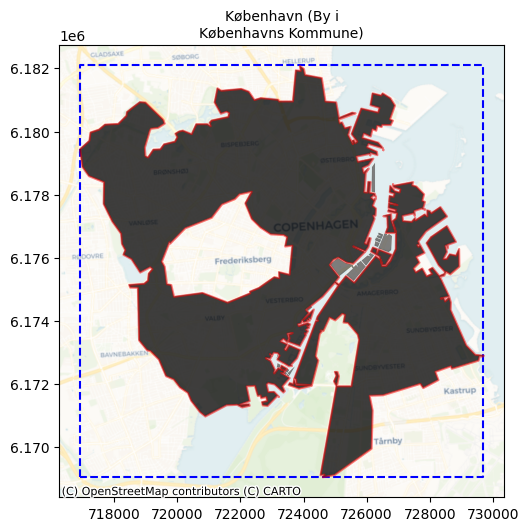

In [145]:
plot_results(copenhagen, 3, 3)

### Aalborg

In [146]:
aalborg = api_request(url, token, "Aalborg (By i Aalborg Kommune)")
aalborg

Got 1 results for query 'Aalborg (By i Aalborg Kommune)'.


,id,skrivemaade,skrivemaade_officiel,skrivemaade_uofficiel,visningstekst,stednavn_type,stednavn_subtype,kommunekode,bbox,geometry
0,12337669-a143-6b98-e053-d480220a5a3f,Aalborg,Aalborg,None,Aalborg (By i Aalborg Kommune),bebyggelse,by,0851,"POLYGON ((551811.0263 6316283.03, 551811.0263 ...","POLYGON ((552399.379 6320175.041, 552488.015 6..."


There is 1 geometry.


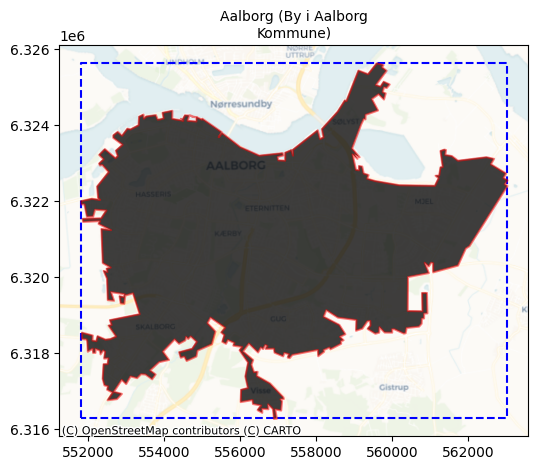

In [147]:
plot_results(aalborg, 4, 3)

### Aarhus

Got 1 results for query 'Aarhus (By i Aarhus Kommune)'.


,id,skrivemaade,skrivemaade_officiel,skrivemaade_uofficiel,visningstekst,stednavn_type,stednavn_subtype,kommunekode,bbox,geometry
0,12337669-a188-6b98-e053-d480220a5a3f,Aarhus,Aarhus,None,Aarhus (By i Aarhus Kommune),bebyggelse,by,0751,"POLYGON ((564978.1805 6215437.202, 564978.1805...","MULTIPOLYGON (((575504.662 6222134.392, 575574..."


There are 2 geometries.


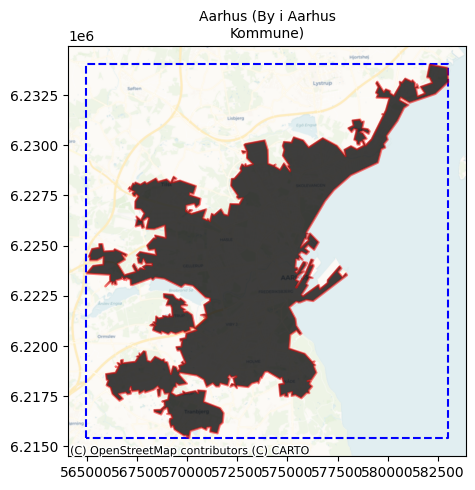

In [149]:
aarhus = api_request(url, token, "Aarhus (By i Aarhus Kommune)")
display(aarhus)
plot_results(aarhus,1,1)

### Esbjerg

Got 1 results for query 'Esbjerg (By i Esbjerg Kommune)'.


,id,skrivemaade,skrivemaade_officiel,skrivemaade_uofficiel,visningstekst,stednavn_type,stednavn_subtype,kommunekode,bbox,geometry
0,12337669-a544-6b98-e053-d480220a5a3f,Esbjerg,Esbjerg,None,Esbjerg (By i Esbjerg Kommune),bebyggelse,by,0561,"POLYGON ((458447.7 6144971.2635, 458447.7 6155...","POLYGON ((462949.498 6153933.58, 462839.618 61..."


There is 1 geometry.


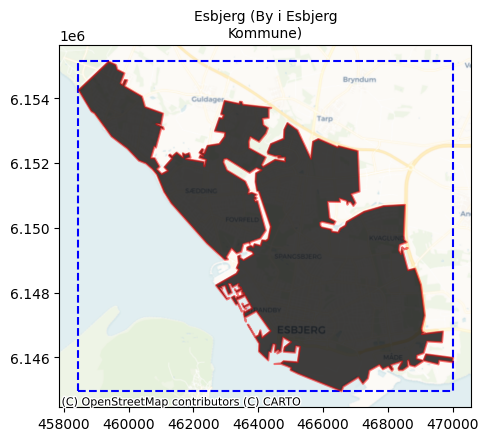

In [150]:
esbjerg = api_request(url, token, "Esbjerg (By i Esbjerg Kommune)")
display(esbjerg)
plot_results(esbjerg,1,1)

### Vejle

Got 1 results for query 'Vejle (By i Vejle Kommune)'.


,id,skrivemaade,skrivemaade_officiel,skrivemaade_uofficiel,visningstekst,stednavn_type,stednavn_subtype,kommunekode,bbox,geometry
0,30fb55ec-9c1d-4019-e053-d380220a510f,Vejle,Vejle,None,Vejle (By i Vejle Kommune),bebyggelse,by,0630,"POLYGON ((530878.6477 6169056.7047, 530878.647...","POLYGON ((531042.215 6175715.481, 530977.526 6..."


There is 1 geometry.


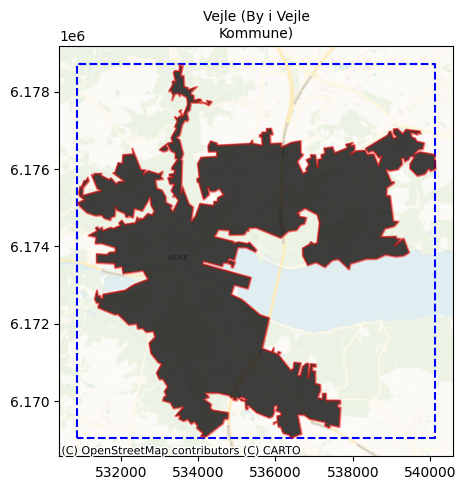

In [151]:
vejle = api_request(url, token, "Vejle (By i Vejle Kommune)")
display(vejle)
plot_results(vejle,1,1)

## Save .geojson files

In [152]:
boundaries_path = "../cities/boundaries"

# Aalborg
aalborg_proj = aalborg.to_crs("EPSG:4326")
aalborg_proj["geometry"] = aalborg_proj["geometry"].apply(
    lambda g: max(g.geoms, key=lambda p: p.area) if hasattr(g, "geoms") else g
)
aalborg_proj.to_file(f"{boundaries_path}/aalborg_dk.geojson")

# Aarhus
aarhus_proj = aarhus.to_crs("EPSG:4326")
aarhus_proj["geometry"] = aarhus_proj["geometry"].apply(
    lambda g: max(g.geoms, key=lambda p: p.area) if hasattr(g, "geoms") else g
)
aarhus_proj.to_file(f"{boundaries_path}/aarhus_dk.geojson")

# Esbjerg
esbjerg_proj = esbjerg.to_crs("EPSG:4326")
esbjerg_proj["geometry"] = esbjerg_proj["geometry"].apply(
    lambda g: max(g.geoms, key=lambda p: p.area) if hasattr(g, "geoms") else g
)
esbjerg_proj.to_file(f"{boundaries_path}/esbjerg_dk.geojson")

# Vejle
vejle_proj = vejle.to_crs("EPSG:4326")
vejle_proj["geometry"] = vejle_proj["geometry"].apply(
    lambda g: max(g.geoms, key=lambda p: p.area) if hasattr(g, "geoms") else g
)
vejle_proj.to_file(f"{boundaries_path}/vejle_dk.geojson")